In [2]:
from typing import List

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy.stats import genpareto, lognorm

### Pandemics w severity over time

In [3]:
df = pd.read_excel("../data/epidemics_marani_240816.xlsx")

In [4]:
resolve_nan_cols = ['severity_smu', 'severity_perthousand', 'death_thousand']
for col in resolve_nan_cols:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)

In [5]:
yrmin = 1900
plot1_df = df[df['year_start'] >= yrmin]

In [6]:
def create_epidemic_timeline(df, grey_threshold: float = 0, grey_non_vira = False, color_diseases: List = None):
    """
    Create a timeline visualization of epidemic outbreaks
    
    Parameters:
    df (pandas.DataFrame): DataFrame with columns:
        - 'start_year': Start year of the epidemic
        - 'end_year': End year of the epidemic
        - 'deaths_per_thousand': Severity of the epidemic
        - 'name': Name of the epidemic (optional)
    grey_threshold (float): a severity threshold under which to make lines grey
    grey_non_vira (bool): Grey non viral epidemics
    
    Returns:
    matplotlib.figure.Figure: Plotted figure of epidemic timeline
    """
    # Calculate duration and intensity
    df['intensity'] = df['severity_smu'] / df['duration']
    
    # Create the plot
    plt.figure(figsize=(18, 10))
    
    # Sort dataframe by start year
    df_sorted = df.sort_values('year_start')
    
    # Plot each epidemic as a horizontal line
    for i, (_, row) in enumerate(df_sorted.iterrows()):
        # Log-scale the line width based on intensity
        line_width = max(0.5, np.log2(row['intensity'] + 1))
        non_viral_color = 'grey' if grey_non_vira else 'blue'
        color = 'red' if bool(row['is_vira_only']) else non_viral_color

        if row['severity_smu'] <= grey_threshold or pd.isna(row['severity_smu']):
            color = 'grey'

                    # Label pandemics with high intensity (you can adjust the threshold)
        if not color_diseases:
          if row['intensity'] > 0.5:  # Example threshold
              plt.text(row['year_end'] + 1, i, f" {row['disease']}", 
                      verticalalignment='center', fontsize=9)
        else:
          if not row['disease'] in color_diseases:
              color = 'grey'
          elif row['severity_smu'] <= grey_threshold or pd.isna(row['severity_smu']):
              color = 'grey'
          else:
              plt.text(row['year_end'] + 1, i, f" {row['disease']}", 
                      verticalalignment='center', fontsize=9)

        # Plot the epidemic timeline
        plt.hlines(y=i, xmin=row['year_start'], xmax=row['year_end'], 
                   linewidth=line_width, color=color, alpha=0.8)
        
    # Customize the plot
    plt.title('Epidemic Outbreaks Timeline', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Epidemics', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.8)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

      # Create custom legend
    viral_patch = mpatches.Patch(color='red', label='Viral Epidemics')
    non_viral_patch = mpatches.Patch(color='blue', label='Non-Viral Epidemics')
    plt.legend(handles=[viral_patch, non_viral_patch], loc='lower right')
    
    # Remove y-axis ticks
    plt.yticks([])
    plt.tight_layout()
    
    return plt

C:\Users\squaade\AppData\Local\Temp\ipykernel_20336\2245308538.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intensity'] = df['severity_smu'] / df['duration']


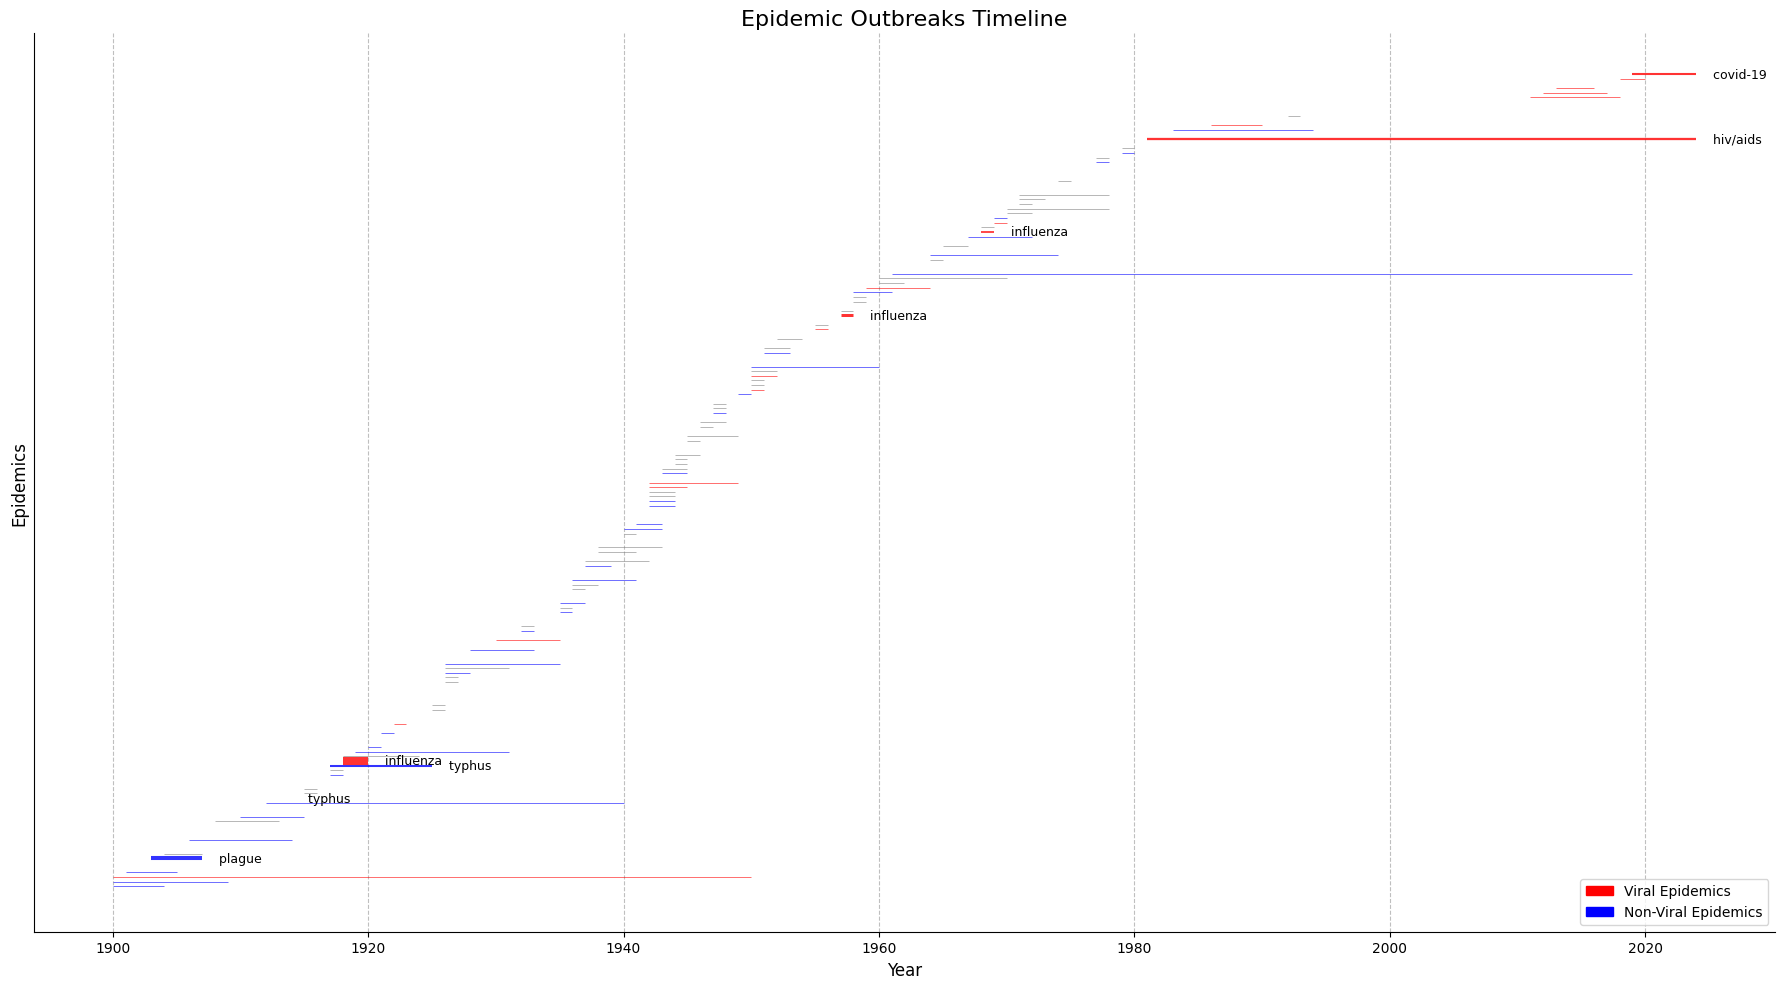

In [7]:
# Without greying treshold
plot = create_epidemic_timeline(plot1_df)
plot.savefig("../graphs/12_epidemics_over_time.jpg", dpi=400)

C:\Users\squaade\AppData\Local\Temp\ipykernel_20336\2245308538.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intensity'] = df['severity_smu'] / df['duration']


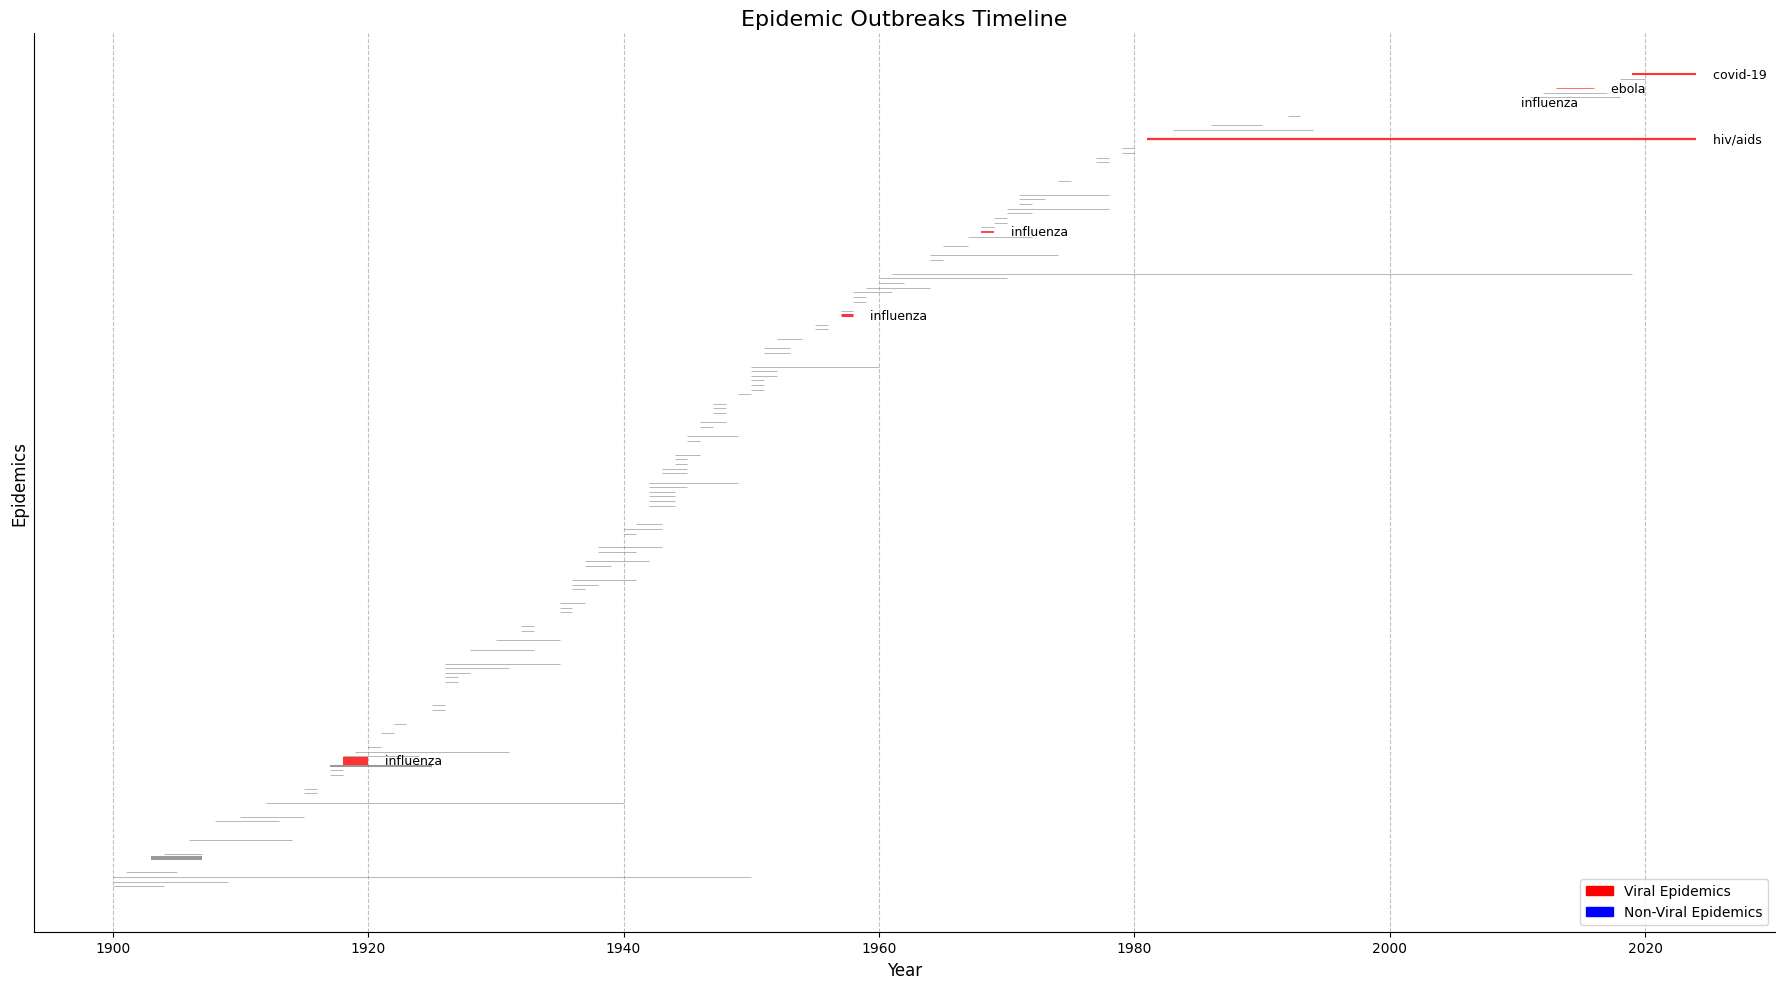

In [8]:
# Without greying treshold
keep_diseases = ['influenza', 'covid-19', 'ebola', 'hiv/aids']
plot = create_epidemic_timeline(plot1_df, grey_threshold=0.01, grey_non_vira=True, color_diseases=keep_diseases)
plot.savefig("../graphs/12_epidemics_over_time.jpg", dpi=400)

### Severity distribution with data points

In [9]:
with open("../output/arrival_distributions/all_risk_gamma_0.6.yaml") as f:
    severity_config = yaml.safe_load(f)

severity_params = severity_config['params']

In [10]:
severity_dist = genpareto(
  loc=severity_params['theta'],
  c=severity_params['k'],
  scale=severity_params['sigma']
)

In [11]:
plot2_df = plot1_df[(plot1_df['severity_smu'] >= 0.01) & (plot1_df['is_vira_only'] == 1)]
plot2_df = plot2_df[plot2_df['disease'].isin(['influenza', 'covid-19', 'ebola', 'hiv/aids'])]

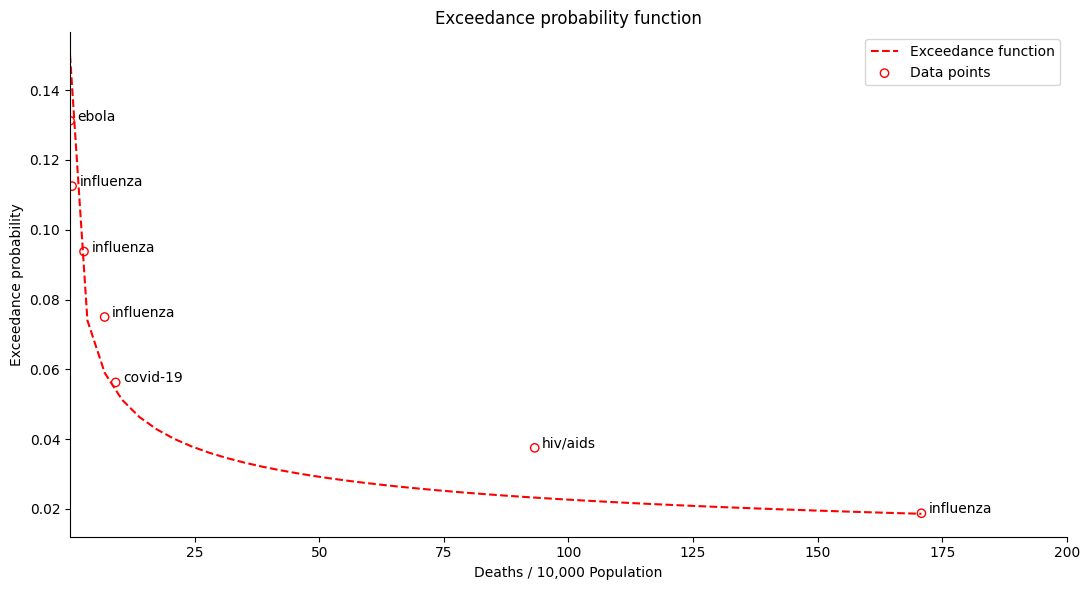

In [12]:
annual_pandemic_risk = severity_config['min_severity_exceed_prob']

x = np.linspace(severity_params['theta'], severity_config['max_severity'])
exceedance = (1 - severity_dist.cdf(x)) * annual_pandemic_risk

## Create a ranked df by historical severities 
plot2_df = plot2_df.sort_values(
  by='severity_smu', 
  ascending=False
).reset_index(drop=True)

## Calculate exceedance conditional on known-severity arrival
plot2_df['exceed_empirical'] = (
    annual_pandemic_risk * (plot2_df.index + 1) / (plot2_df.shape[0] + 1)
)

# Create fig
plt.figure(figsize=(11, 6))

# Plot
plt.plot(x, exceedance, color='red', linestyle='--', label='Exceedance function')
plt.scatter(plot2_df['severity_smu'], plot2_df['exceed_empirical'], marker='o', color='red', facecolor='none', label='Data points')

# Add text labels
for idx, r in plot2_df.iterrows():
    plt.text(r['severity_smu'] + 1.5, r['exceed_empirical'], r['disease'])

# Style figure
plt.xlim(severity_params['theta'], 200)
plt.xlabel("Deaths / 10,000 Population")
plt.ylabel("Exceedance probability")
plt.title("Exceedance probability function")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()

### Duration distribution with data points

In [13]:
with open("../output/duration_distributions/all_risk_gamma_0.6.yaml") as f:
    duration_config = yaml.safe_load(f)

duration_params = duration_config['params']

In [25]:
duration_dist = lognorm(scale=np.exp(duration_params['mu']), s=duration_params['sigma'])

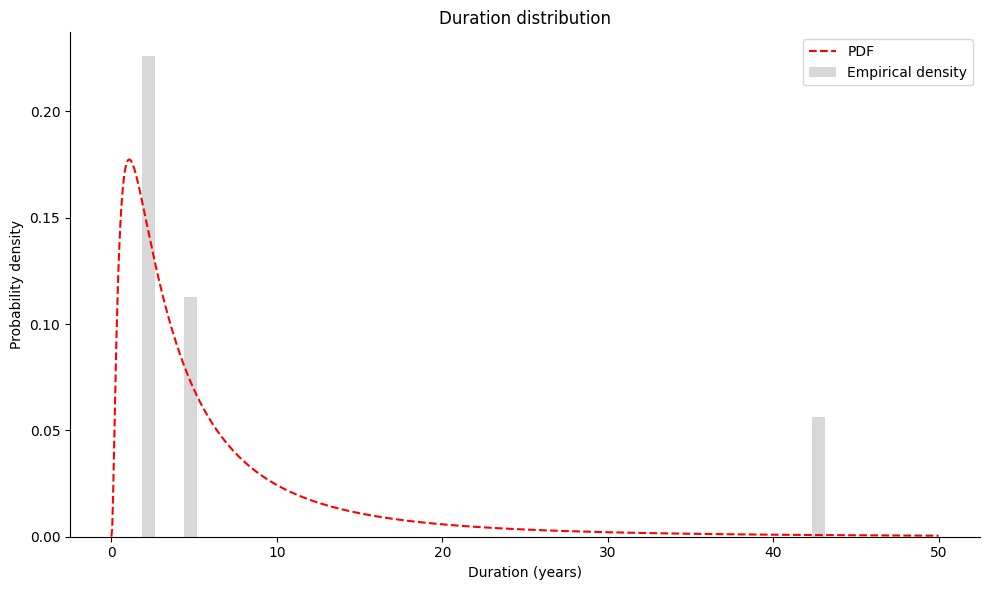

In [29]:
x = np.linspace(0, 50, 1000)
pdf_vals = duration_dist.pdf(x)

# Empirical probability densities
plot2_df = plot2_df.sort_values('duration').reset_index(drop=True)
empirical_densities, bins = np.histogram(plot2_df['duration'], bins='auto', density=True)
bin_centers = (bins[1:]+bins[:-1])*0.5

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_vals, color='red', linestyle='--', label="PDF")
plt.bar(bin_centers, empirical_densities, color='grey', alpha=.3, label='Empirical density')

plt.xlabel("Duration (years)")
plt.ylabel("Probability density")
plt.title("Duration distribution")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()